# Step 4 - ARIMA Baseline Walkthrough

This notebook is the tutorial version of `src/04_arima.py`.

Audience:
- Readers who are new to ARIMA and want to see the full modeling workflow, including more serious backtesting.

Prerequisites:
- Basic pandas familiarity
- A rough idea of train versus validation splits
- Step 3's conclusion that the log series needs one difference

Learning goals:
- See why this project searches `ARIMA(p,1,q)`
- Use AIC to compare model orders
- Validate the winner on 2023-2024
- Run an expanding-window backtest against simple baselines
- Save the same forecast, backtest, and model artifacts as the script


## Outline

1. Set up imports and project paths
2. Load the annual import series and define the train/validation split
3. Search candidate ARIMA orders
4. Fit the winning model and score the 2023-2024 holdout
5. Run an expanding-window backtest against simple baselines
6. Refit on the full history and forecast 2025-2027
7. Save the CSV outputs, charts, model summary, and model pickle
8. Try a short exercise


In [1]:
from pathlib import Path
import os
import pickle
import sys
import warnings

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(path for path in candidates if (path / "config.py").exists())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA

from config import (
    ANNUAL_FILE,
    CHART_DIR,
    EVAL_FILE,
    FORECAST_FILE_ARIMA,
    FORECAST_YEARS,
    MODEL_DIR,
    REPORT_DIR,
    TRAIN_END_YEAR,
    VAL_START_YEAR,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings(
    "ignore",
    message="Non-stationary starting autoregressive parameters found.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="Non-invertible starting MA parameters found.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive.*",
    category=UserWarning,
)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

NAVY = "#0f2744"
BLUE = "#1d4ed8"
AMBER = "#f59e0b"
GRAY = "#64748b"
BACKTEST_MIN_TRAIN_SIZE = 12

PROJECT_ROOT


WindowsPath('C:/Users/Pegasus/Desktop/SemiTrack2')

## Load the series and set up the split

ARIMA needs one ordered target series. We use annual real imports, take logs, train through 2022, and keep 2023-2024 aside as a simple holdout check before forecasting 2025-2027.


In [2]:
ann = pd.read_csv(ANNUAL_FILE)
ann["year"] = ann["year"].astype(int)
ann = ann.sort_values("year").reset_index(drop=True)

y = np.log(ann["real_value_2015usd_billions"])
years = ann["year"].to_numpy()
train_mask = ann["year"] <= TRAIN_END_YEAR
val_mask = ann["year"] >= VAL_START_YEAR
y_train = y[train_mask]
y_val = y[val_mask]

pd.DataFrame(
    {
        "segment": ["training", "validation", "forecast horizon"],
        "start_year": [int(ann.loc[train_mask, "year"].min()), int(ann.loc[val_mask, "year"].min()), FORECAST_YEARS[0]],
        "end_year": [TRAIN_END_YEAR, int(ann.loc[val_mask, "year"].max()), FORECAST_YEARS[-1]],
        "observations": [int(train_mask.sum()), int(val_mask.sum()), len(FORECAST_YEARS)],
    }
)


,segment,start_year,end_year,observations
0,training,1995,2022,28
1,validation,2023,2024,2
2,forecast horizon,2025,2027,3


## Define the helpers used by the notebook and script

We need three pieces of reusable logic: a small ARIMA grid search, a robust forecast helper, and an expanding-window backtest that compares the model against simple baselines.


In [3]:
def select_best_arima_order(series):
    best_aic = np.inf
    best_order = (1, 1, 1)
    rows = []
    for p in range(0, 4):
        for q in range(0, 4):
            if p == 0 and q == 0:
                continue
            try:
                fitted_model = ARIMA(series, order=(p, 1, q)).fit()
                rows.append({"order": f"ARIMA({p},1,{q})", "p": p, "d": 1, "q": q, "aic": fitted_model.aic})
                if fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_order = (p, 1, q)
            except Exception:
                pass
    return best_order, best_aic, pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)


def arima_forecast(fitted_model, y_full_series, steps, order):
    try:
        extended = fitted_model.apply(y_full_series)
        pred = extended.forecast(steps=steps)
        ci_lo = pred * 0.88
        ci_hi = pred * 1.12
        try:
            forecast_obj = extended.get_forecast(steps=steps)
            pred = forecast_obj.predicted_mean
            ci = forecast_obj.conf_int(alpha=0.05)
            ci_lo = ci.iloc[:, 0]
            ci_hi = ci.iloc[:, 1]
        except Exception:
            pass
        return np.array(pred), np.array(ci_lo), np.array(ci_hi)
    except Exception:
        pass
    try:
        refit_model = ARIMA(y_full_series, order=order).fit()
        forecast_obj = refit_model.get_forecast(steps=steps)
        pred = forecast_obj.predicted_mean
        ci = forecast_obj.conf_int(alpha=0.05)
        return np.array(pred), np.array(ci.iloc[:, 0]), np.array(ci.iloc[:, 1])
    except Exception:
        pass
    last_value = float(pd.Series(y_full_series).iloc[-1])
    avg_step = float(pd.Series(y_full_series).diff().dropna().mean())
    pred = np.array([last_value + avg_step * (i + 1) for i in range(steps)])
    return pred, pred - 0.12 * abs(pred), pred + 0.12 * abs(pred)


def rolling_backtest_arima(annual_df, min_train_size=BACKTEST_MIN_TRAIN_SIZE):
    rows = []
    y_log = np.log(annual_df["real_value_2015usd_billions"])
    real_values = annual_df["real_value_2015usd_billions"].to_numpy()
    years = annual_df["year"].to_numpy()
    for idx in range(min_train_size, len(annual_df)):
        train_log = y_log.iloc[:idx]
        actual_real = float(real_values[idx])
        year = int(years[idx])
        naive_last = float(real_values[idx - 1])
        naive_3yr = float(np.mean(real_values[max(0, idx - 3) : idx]))
        order, order_aic, _ = select_best_arima_order(train_log)
        fitted_model = ARIMA(train_log, order=order).fit()
        forecast_log, _, _ = arima_forecast(fitted_model, train_log, 1, order)
        arima_forecast_real = float(np.exp(forecast_log[-1]))
        rows.append(
            {
                "year": year,
                "train_observations": idx,
                "actual_real_bn": actual_real,
                "naive_last_forecast_bn": naive_last,
                "naive_last_ape_pct": abs((actual_real - naive_last) / actual_real) * 100,
                "naive_3yr_forecast_bn": naive_3yr,
                "naive_3yr_ape_pct": abs((actual_real - naive_3yr) / actual_real) * 100,
                "arima_order": str(order),
                "arima_order_aic": order_aic,
                "arima_forecast_bn": arima_forecast_real,
                "arima_ape_pct": abs((actual_real - arima_forecast_real) / actual_real) * 100,
            }
        )
    return pd.DataFrame(rows)


## Run the order search and inspect the best candidates

This is the model-selection step for the main training window. The lowest-AIC order becomes the baseline ARIMA specification used for the held-out validation and the final forecast.


In [4]:
best_order, best_aic, grid_df = select_best_arima_order(y_train)
grid_df.insert(0, "rank", np.arange(1, len(grid_df) + 1))
grid_df[["rank", "order", "aic"]].head(10)


,rank,order,aic
0,1,"ARIMA(1,1,0)",21.2527
1,2,"ARIMA(0,1,1)",21.2543
2,3,"ARIMA(1,1,1)",22.7810
3,4,"ARIMA(2,1,0)",23.1923
4,5,"ARIMA(0,1,2)",23.1940
5,6,"ARIMA(2,1,2)",23.8435
6,7,"ARIMA(0,1,3)",24.6778
7,8,"ARIMA(1,1,2)",24.7274
8,9,"ARIMA(3,1,0)",24.7590
9,10,"ARIMA(3,1,2)",25.0652


## Fit the winning model and score the 2023-2024 holdout

This is the original simple validation step: fit through 2022, forecast the held-out years, and compute the usual error metrics.


In [5]:
model = ARIMA(y_train, order=best_order).fit()
val_steps = int(val_mask.sum())
val_years = ann.loc[val_mask, "year"].to_numpy()
y_val_actual = y_val.to_numpy()
forecast_val, _, _ = arima_forecast(model, y, val_steps, best_order)
forecast_val = forecast_val[-val_steps:] if len(forecast_val) > val_steps else forecast_val

mae_val = np.mean(np.abs(y_val_actual - forecast_val))
rmse_val = np.sqrt(np.mean((y_val_actual - forecast_val) ** 2))
mape_val = np.mean(np.abs((np.exp(y_val_actual) - np.exp(forecast_val)) / np.exp(y_val_actual))) * 100

pd.DataFrame(
    {
        "metric": ["MAE (log scale)", "RMSE (log scale)", "MAPE (real scale, %)"],
        "value": [mae_val, rmse_val, mape_val],
    }
)


,metric,value
0,MAE (log scale),0.0722
1,RMSE (log scale),0.0993
2,"MAPE (real scale, %)",7.7329


## Run an expanding-window backtest against simple baselines

This is the stronger evaluation step. Instead of judging the model on only 2023-2024, we repeatedly train on the past and forecast the next year, then compare ARIMA against two simple baselines:
- repeat the last observed value
- use the trailing 3-year average


In [6]:
backtest_df = rolling_backtest_arima(ann)
backtest_df.head()


,year,train_observations,actual_real_bn,naive_last_forecast_bn,naive_last_ape_pct,naive_3yr_forecast_bn,naive_3yr_ape_pct,arima_order,arima_order_aic,arima_forecast_bn,arima_ape_pct
0,2007,12,1.3987,1.2288,12.1470,1.0648,23.8746,"(1, 1, 0)",-2.2114,1.0731,23.2756
1,2008,13,0.9333,1.3987,49.8661,1.2149,30.1761,"(1, 1, 0)",-1.8762,1.2996,39.2514
2,2009,14,2.2859,0.9333,59.1714,1.1869,48.0759,"(1, 1, 0)",-0.5026,1.2232,46.4889
3,2010,15,2.3982,2.2859,4.6827,1.5393,35.8144,"(1, 1, 0)",5.0796,1.0417,56.5640
4,2011,16,2.5286,2.3982,5.1570,1.8725,25.9485,"(1, 1, 0)",9.5997,2.3522,6.9747


## Summarize which approach wins more often

Mean error is useful, but it can still hide whether a model wins consistently or only occasionally. This summary table makes the backtest easier to read quickly.


In [7]:
backtest_summary = pd.DataFrame(
    {
        "method": ["Naive last value", "Naive 3-year mean", "ARIMA"],
        "mean_APE_pct": [
            backtest_df["naive_last_ape_pct"].mean(),
            backtest_df["naive_3yr_ape_pct"].mean(),
            backtest_df["arima_ape_pct"].mean(),
        ],
        "median_APE_pct": [
            backtest_df["naive_last_ape_pct"].median(),
            backtest_df["naive_3yr_ape_pct"].median(),
            backtest_df["arima_ape_pct"].median(),
        ],
    }
)
backtest_summary


,method,mean_APE_pct,median_APE_pct
0,Naive last value,24.1405,20.7417
1,Naive 3-year mean,31.5951,26.6711
2,ARIMA,28.3914,27.0153


## Visualize the backtest errors by year

A single average can hide regime changes. This chart shows whether ARIMA wins steadily or only in certain years.


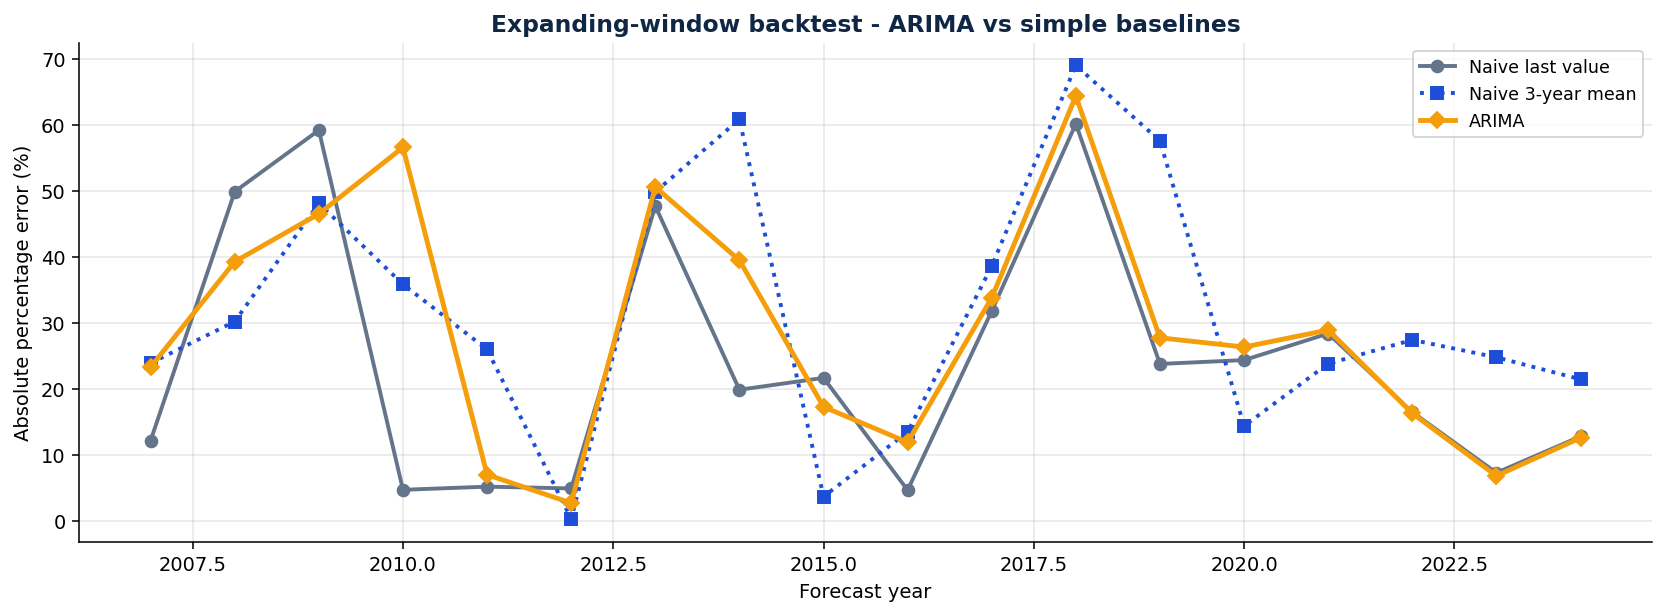

In [8]:
backtest_chart_path = Path(CHART_DIR) / "arima_04_backtest.png"
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(backtest_df["year"], backtest_df["naive_last_ape_pct"], color=GRAY, lw=2, marker="o", label="Naive last value")
ax.plot(backtest_df["year"], backtest_df["naive_3yr_ape_pct"], color=BLUE, lw=2, marker="s", linestyle=":", label="Naive 3-year mean")
ax.plot(backtest_df["year"], backtest_df["arima_ape_pct"], color=AMBER, lw=2.5, marker="D", label="ARIMA")
ax.set_xlabel("Forecast year")
ax.set_ylabel("Absolute percentage error (%)")
ax.set_title("Expanding-window backtest - ARIMA vs simple baselines", fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(backtest_chart_path)
plt.show()
plt.close(fig)


## Refit on the full history and forecast 2025-2027

After checking both the simple holdout and the rolling backtest, we fit the model on the full series and create the forward forecast used by the rest of the project.


In [9]:
model_full = ARIMA(y, order=best_order).fit()
fc_steps = len(FORECAST_YEARS)
fc_log_mean, fc_log_lo, fc_log_hi = arima_forecast(model_full, y, fc_steps, best_order)
fc_real_mean = np.exp(fc_log_mean[-fc_steps:])
fc_real_lo = np.exp(fc_log_lo[-fc_steps:])
fc_real_hi = np.exp(fc_log_hi[-fc_steps:])

fc_df = pd.DataFrame(
    {
        "year": FORECAST_YEARS,
        "arima_forecast_bn": list(fc_real_mean),
        "ci_lower_bn": list(fc_real_lo),
        "ci_upper_bn": list(fc_real_hi),
        "order": [str(best_order)] * fc_steps,
        "aic": [round(best_aic, 2)] * fc_steps,
    }
)
fc_df


,year,arima_forecast_bn,ci_lower_bn,ci_upper_bn,order,aic
0,2025,14.6696,7.7954,27.6055,"(1, 1, 0)",21.2500
1,2026,14.6721,5.9039,36.4625,"(1, 1, 0)",21.2500
2,2027,14.6722,4.7780,45.0557,"(1, 1, 0)",21.2500


## Save the forecast CSV, validation CSV, backtest CSV, and model pickle

The notebook keeps the same side effects as the script and also saves the fitted ARIMA model so you can reload it later from `outputs/models`.


In [10]:
fc_df.to_csv(FORECAST_FILE_ARIMA, index=False)

eval_rows = []
for year, actual_log, pred_log in zip(val_years, y_val_actual, forecast_val):
    actual_real = np.exp(actual_log)
    pred_real = np.exp(pred_log)
    eval_rows.append(
        {
            "year": year,
            "actual_log": round(actual_log, 4),
            "forecast_log": round(pred_log, 4),
            "actual_real_bn": round(actual_real, 4),
            "forecast_real_bn": round(pred_real, 4),
            "error_bn": round(actual_real - pred_real, 4),
            "pct_error": round((actual_real - pred_real) / actual_real * 100, 2),
        }
    )
eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(EVAL_FILE, index=False)

backtest_path = Path(REPORT_DIR) / "arima_backtest.csv"
backtest_df.to_csv(backtest_path, index=False)

model_path = Path(MODEL_DIR) / "arima_model.pkl"
with open(model_path, "wb") as file_handle:
    pickle.dump(model_full, file_handle)

pd.DataFrame(
    {
        "artifact": ["Forecast CSV", "Validation CSV", "Backtest CSV", "Saved model"],
        "path": [FORECAST_FILE_ARIMA, EVAL_FILE, str(backtest_path), str(model_path)],
    }
)


,artifact,path
0,Forecast CSV,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...
1,Validation CSV,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...
2,Backtest CSV,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...
3,Saved model,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\mo...


## Save the original forecast and diagnostic charts

These are the same main visuals from the script: the forecast view, the residual diagnostics, and the AIC heatmap.


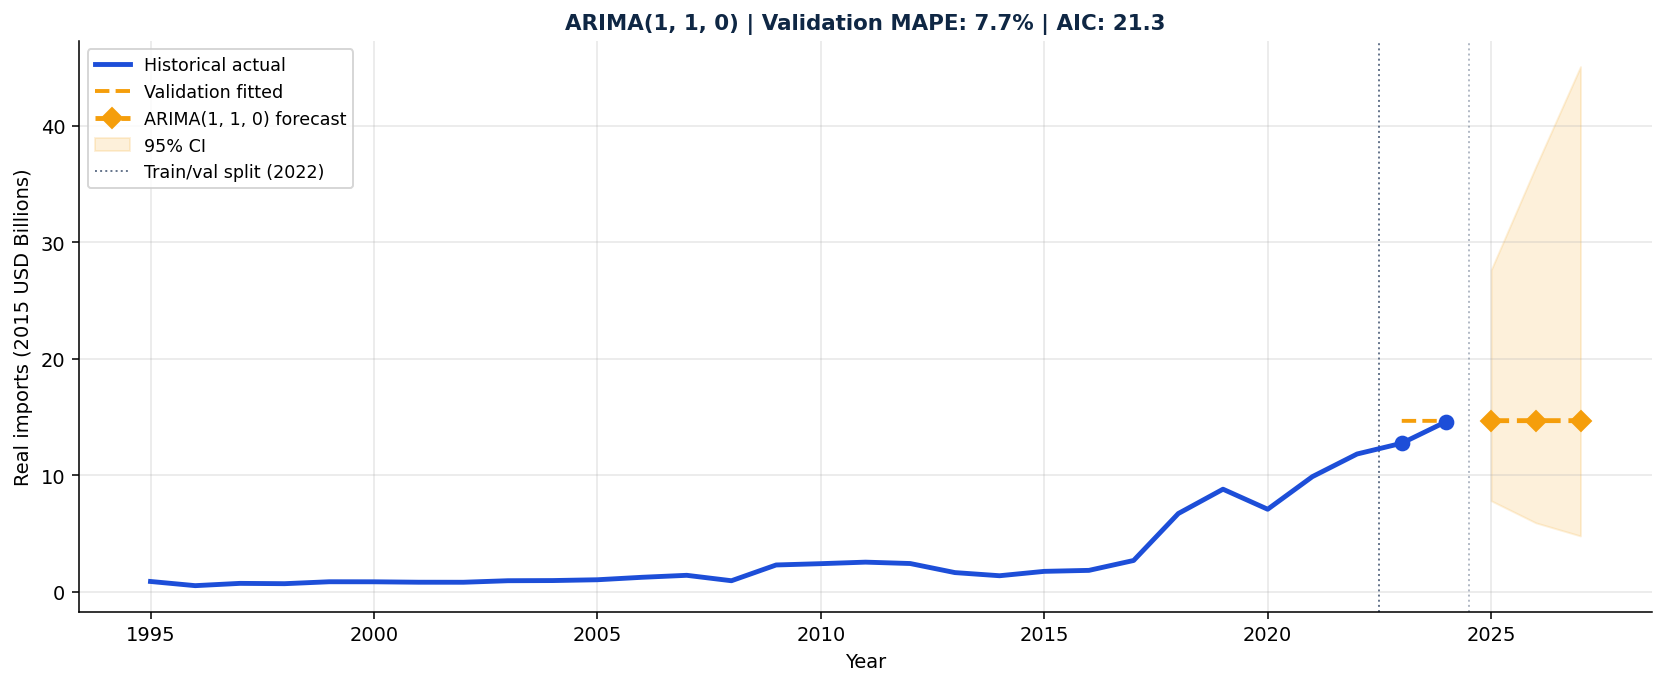

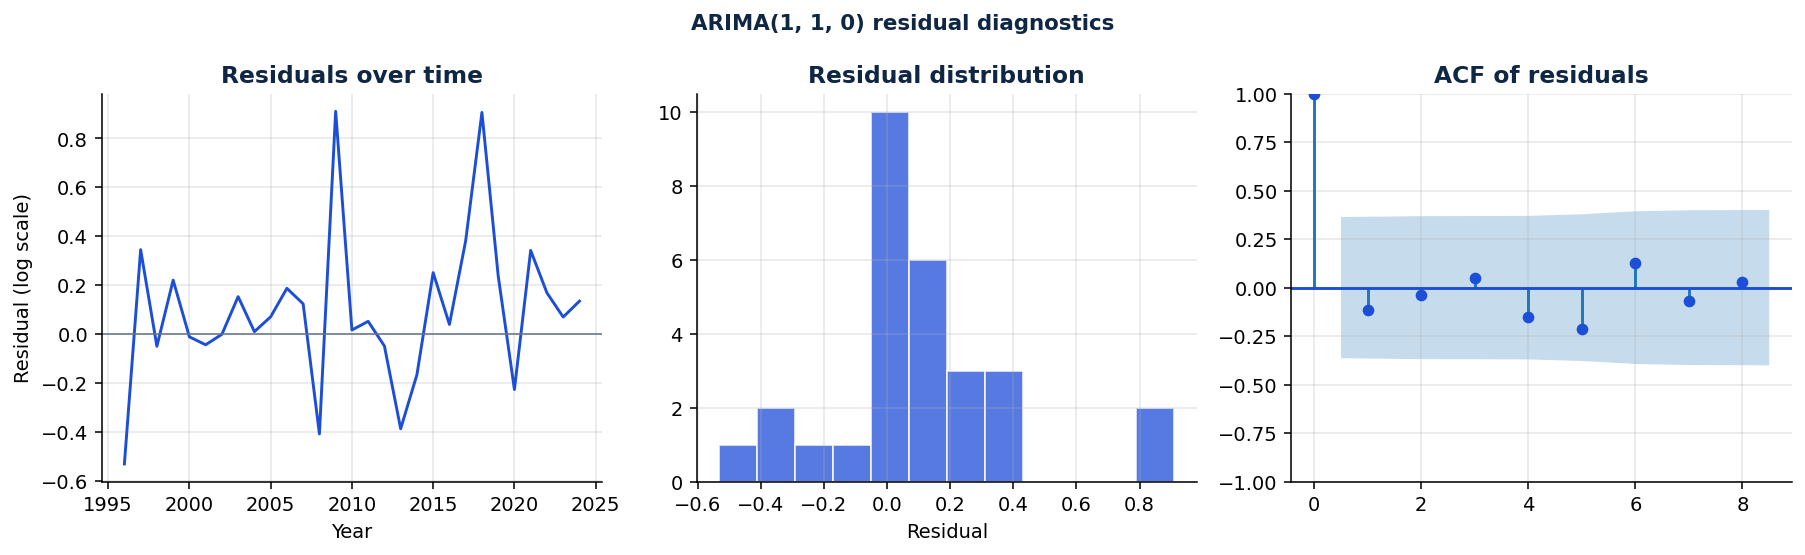

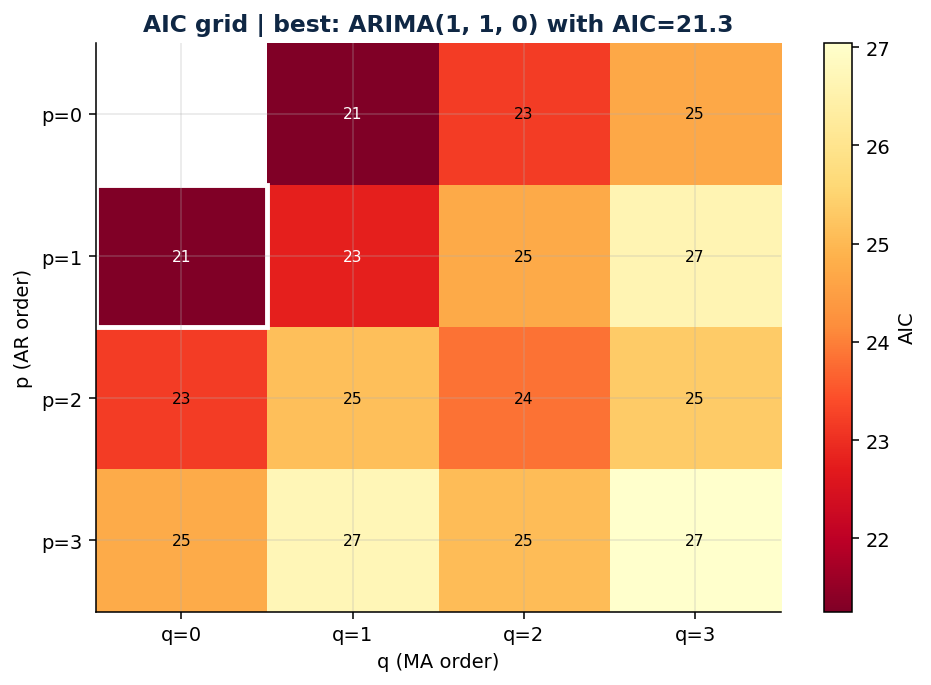

,chart,path
0,Forecast chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
1,Residual chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
2,AIC heatmap,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
3,Backtest chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...


In [11]:
forecast_chart_path = Path(CHART_DIR) / "arima_01_forecast.png"
fig, ax = plt.subplots(figsize=(12, 5))
real_vals = np.exp(y)
ax.plot(years, real_vals, color=BLUE, lw=2.5, label="Historical actual", zorder=3)
ax.plot(val_years, np.exp(forecast_val), color=AMBER, lw=2, linestyle="--", label="Validation fitted", zorder=4)
ax.scatter(val_years, np.exp(y_val_actual), color=BLUE, s=50, zorder=5)
ax.plot(FORECAST_YEARS, fc_real_mean, color=AMBER, lw=2.5, linestyle="--", marker="D", markersize=7, label=f"ARIMA{best_order} forecast", zorder=4)
ax.fill_between(FORECAST_YEARS, fc_real_lo, fc_real_hi, color=AMBER, alpha=0.15, label="95% CI")
ax.axvline(TRAIN_END_YEAR + 0.5, color=GRAY, lw=1, linestyle=":", label=f"Train/val split ({TRAIN_END_YEAR})")
ax.axvline(2024.5, color=GRAY, lw=1, linestyle=":", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Real imports (2015 USD Billions)")
ax.set_title(f"ARIMA{best_order} | Validation MAPE: {mape_val:.1f}% | AIC: {best_aic:.1f}", fontsize=11, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(forecast_chart_path)
plt.show()
plt.close(fig)

residual_chart_path = Path(CHART_DIR) / "arima_02_residuals.png"
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
residuals = model_full.resid
axes[0].plot(years[1:], residuals[1:], color=BLUE, lw=1.5)
axes[0].axhline(0, color=GRAY, lw=0.8)
axes[0].set_title("Residuals over time", fontweight="bold", color=NAVY)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Residual (log scale)")
axes[1].hist(residuals[1:], bins=12, color=BLUE, alpha=0.75, edgecolor="white")
axes[1].set_title("Residual distribution", fontweight="bold", color=NAVY)
axes[1].set_xlabel("Residual")
plot_acf(residuals[1:], lags=min(8, len(residuals) // 2 - 2), ax=axes[2], color=BLUE, title="")
axes[2].set_title("ACF of residuals", fontweight="bold", color=NAVY)
plt.suptitle(f"ARIMA{best_order} residual diagnostics", fontsize=11, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.savefig(residual_chart_path)
plt.show()
plt.close(fig)

aic_chart_path = None
if not grid_df.empty:
    pivot = grid_df.pivot(index="p", columns="q", values="aic")
    aic_chart_path = Path(CHART_DIR) / "arima_03_aic_grid.png"
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto")
    plt.colorbar(im, ax=ax, label="AIC")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([f"q={value}" for value in pivot.columns])
    ax.set_yticklabels([f"p={value}" for value in pivot.index])
    max_aic = np.nanmax(pivot.values)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            if pd.notna(value):
                text_color = "white" if value < max_aic * 0.85 else "black"
                ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8, color=text_color)
    bp, bq = best_order[0], best_order[2]
    bi = list(pivot.index).index(bp)
    bj = list(pivot.columns).index(bq)
    ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor="white", lw=2.5))
    ax.set_title(f"AIC grid | best: ARIMA{best_order} with AIC={best_aic:.1f}", fontweight="bold", color=NAVY)
    ax.set_xlabel("q (MA order)")
    ax.set_ylabel("p (AR order)")
    plt.tight_layout()
    plt.savefig(aic_chart_path)
    plt.show()
    plt.close(fig)

pd.DataFrame(
    {
        "chart": ["Forecast chart", "Residual chart", "AIC heatmap", "Backtest chart"],
        "path": [str(forecast_chart_path), str(residual_chart_path), str(aic_chart_path) if aic_chart_path is not None else "", str(backtest_chart_path)],
    }
)


## Save the summary report

The text summary now includes the original model summary plus a short backtest comparison so you can inspect both the fitted model and the broader forecasting behavior from one file.


In [12]:
summary_path = Path(REPORT_DIR) / "arima_summary.txt"
summary_lines = [str(model_full.summary()), "", "Rolling backtest summary", "=" * 30]
for _, row in backtest_summary.iterrows():
    summary_lines.append(
        f"{row['method']}: mean APE={row['mean_APE_pct']:.2f}% | median APE={row['median_APE_pct']:.2f}%"
    )
summary_lines.append(f"Backtest CSV: {backtest_path}")
summary_lines.append(f"Model pickle: {model_path}")
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
str(summary_path)


'C:\\Users\\Pegasus\\Desktop\\SemiTrack2\\outputs\\reports\\arima_summary.txt'